# L19: SDSS Galaxies vs Quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey.\
This is one of the most famous example of machine-learning classification in astronomy.

The dataset is at solutions/galaxyquasar.csv.

**Tasks**

- Create arrays for the $(u - g)$, $(g - r)$ , $(r - i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$.
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

**Ideas**

- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from astroML.classification import GMMBayes
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

In [2]:
path = "/Users/francescarattegni/reps/astrostatistics_bicocca_2025/solutions"
data = pd.read_csv(path+'/galaxyquasar.csv')

In [3]:
data.columns

Index(['u', 'g', 'r', 'i', 'z', 'class', 'z1', 'zerr'], dtype='object')

In [4]:
# Color array
data['u-g'] = data['u'] - data['g']
data['g-r'] = data['g'] - data['r']
data['r-i'] = data['r'] - data['i']
data['i-z'] = data['i'] - data['z']

colors = ['u-g', 'g-r', 'r-i', 'i-z']

In [5]:
print(data['class'])

0           QSO
1        GALAXY
2        GALAXY
3        GALAXY
4           QSO
          ...  
49995    GALAXY
49996    GALAXY
49997    GALAXY
49998    GALAXY
49999    GALAXY
Name: class, Length: 50000, dtype: object


In [6]:
data['target']= data['class'].map({'GALAXY': 0, 'QSO': 1})
print(data['target'])

0        1
1        0
2        0
3        0
4        1
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: target, Length: 50000, dtype: int64


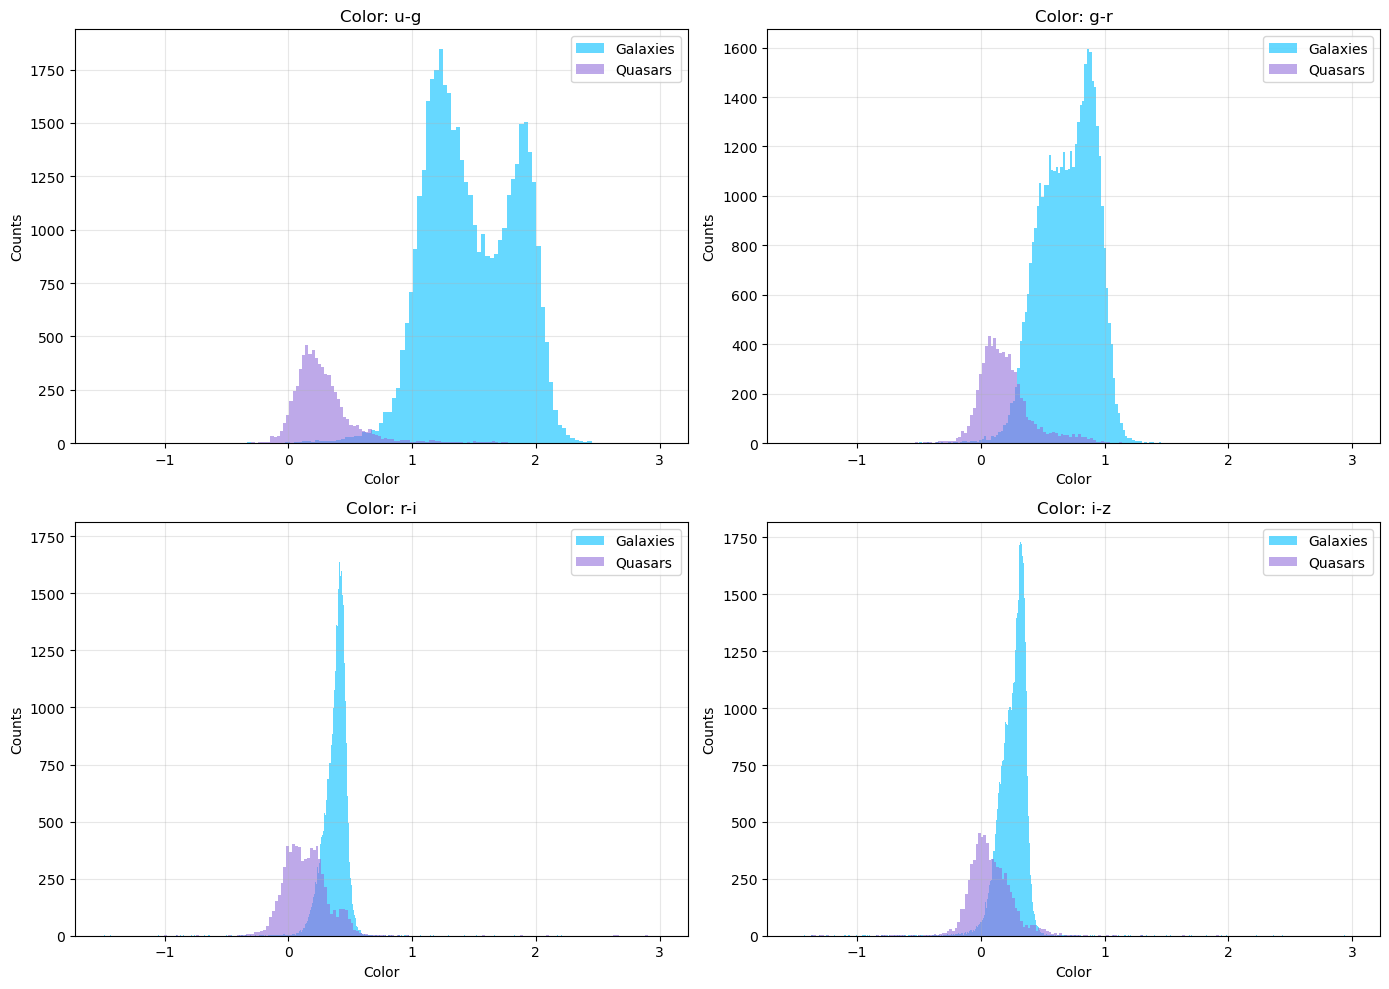

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, color in enumerate(colors):
    galaxies = data[data['target'] == 0][color]
    qso = data[data['target'] == 1][color]

    axes[i].hist(galaxies, bins='fd', range=(-1.5, 3), alpha=0.6, color='deepskyblue', label='Galaxies')
    axes[i].hist(qso, bins='fd', range=(-1.5, 3), alpha=0.6, color='mediumpurple', label='Quasars')

    axes[i].set_title(f'Color: {color}', fontsize=12)
    axes[i].set_xlabel('Color')
    axes[i].set_ylabel('Counts')
    axes[i].legend()
    axes[i].grid(alpha=0.3) 

plt.tight_layout()
plt.show()


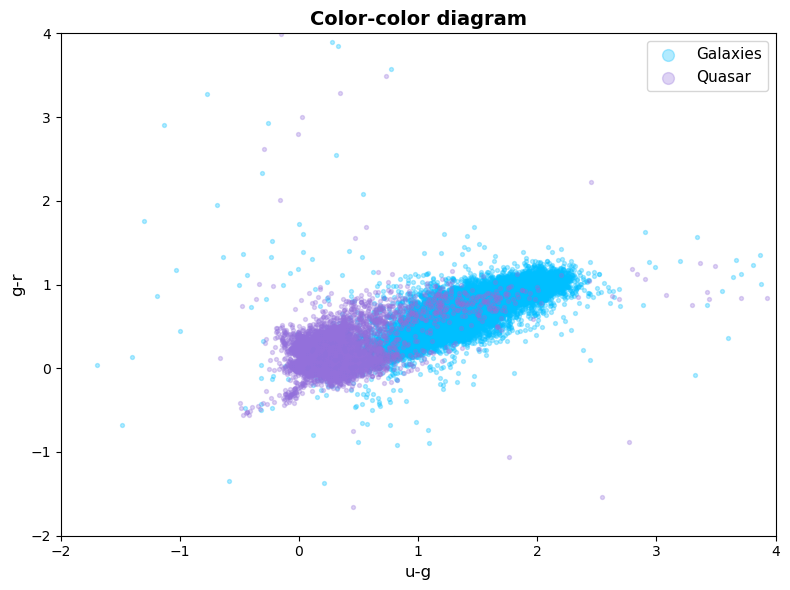

In [8]:
plt.figure(figsize=(8, 6))

gal = data[data['target'] == 0]
qso = data[data['target'] == 1]

plt.scatter(gal['u-g'], gal['g-r'], color='deepskyblue', s=8, alpha=0.3, label='Galaxies') # Galaxies
plt.scatter(qso['u-g'], qso['g-r'], color='mediumpurple', s=8, alpha=0.3, label='Quasar')  # Quasar

plt.xlim(-2, 4)
plt.ylim(-2, 4)

plt.title('Color-color diagram', fontsize=14, fontweight='bold')
plt.xlabel('u-g', fontsize=12)
plt.ylabel('g-r', fontsize=12)

plt.legend(markerscale=3, fontsize=11)

plt.tight_layout()
plt.show()

# Classification
## Naive Bayes

In [9]:
# let's divide the data in training and test set
X = data[colors]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train.shape

(35000, 4)

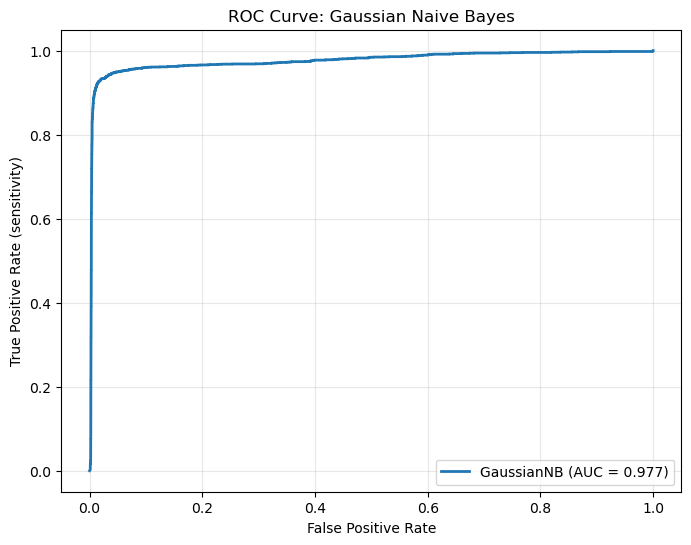

In [11]:
Gaussian_NB = GaussianNB()

Gaussian_NB.fit(X_train ,y_train )
y_prob = Gaussian_NB.predict_proba(X_test) [:,1] 

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f"GaussianNB (AUC = {roc_auc:.3f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: Gaussian Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1: AUC = 0.980104
2: AUC = 0.977316
3: AUC = 0.977188
4: AUC = 0.976770


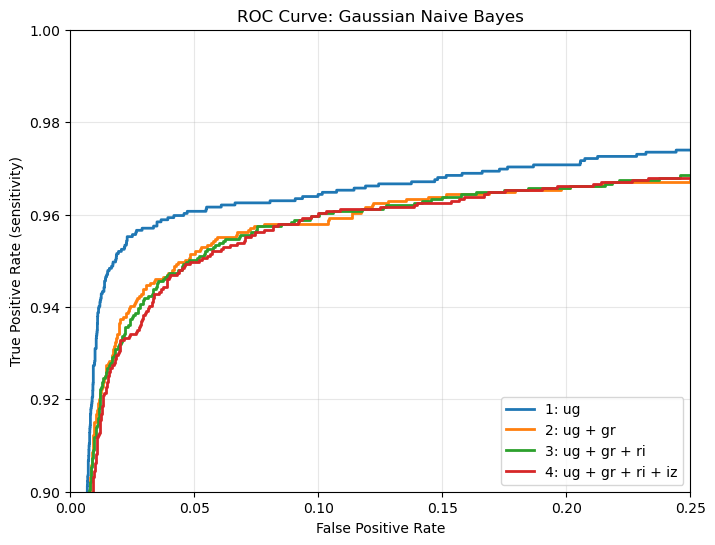

In [12]:
colors_label = ['ug', 'gr', 'ri', 'iz']

plt.figure(figsize=(8,6))

# ROC line -> we try using different colors (a subset of them first, than all together)
for i in range(4):
    
    X_train_subset = X_train.iloc[:, 0:i+1]
    X_test_subset = X_test.iloc[:, 0:i+1]
    
    Gaussian_NB.fit(X_train_subset, y_train)
    
    y_prob = Gaussian_NB.predict_proba(X_test_subset)[:, 1]
    
    # ROC line and AUC
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{i+1}: AUC = {roc_auc:.6f}")
    
    used_colors = " + ".join(colors_label[0:i+1])
    plt.plot(fpr, tpr, lw=2, label=f"{i+1}: {used_colors}")

plt.ylim([0.9, 1])
plt.xlim([0, 0.25])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: Gaussian Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

We notice that AUC is higher if we consider only the first color. Adding the subsequent colors made the model perform worse.\
Quasars are objects powered by supermassive black holes that emit a frightening amount of *ultraviolet radiation*. 
This is why the u-g color is so significant in distinguishing between galaxies and quasars.

However, the Gaussian Naive Bayes model mathematically assumes that the four colors are completely uncorrelated. Let's try other models.

## LDA (Linear Discriminant Analysis) 

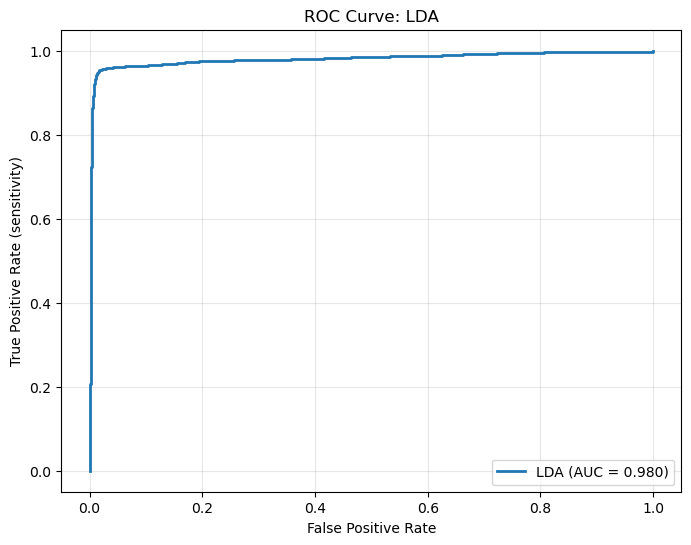

In [13]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train ,y_train )
y_prob = lda.predict_proba(X_test) [:,1] 

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f"LDA (AUC = {roc_auc:.3f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: LDA')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1: AUC = 0.980104
2: AUC = 0.980379
3: AUC = 0.980232
4: AUC = 0.980336


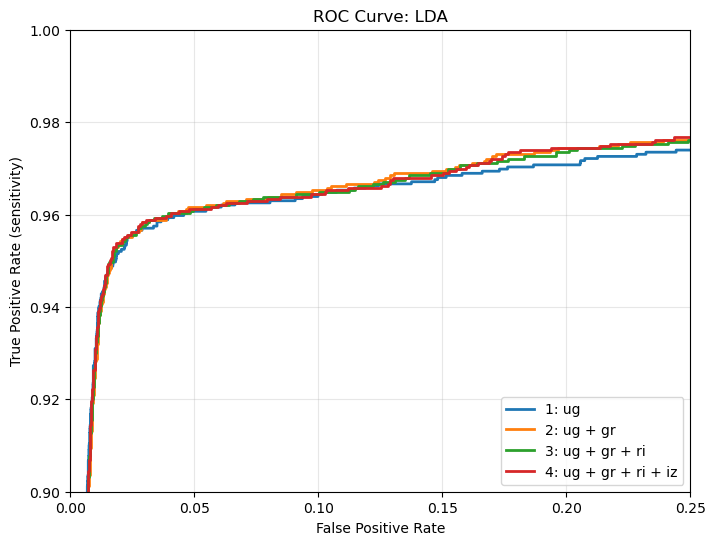

In [14]:
plt.figure(figsize=(8,6))

# ROC line -> we try using different colors (a subset of them first, than all together)
for i in range(4):
    
    X_train_subset = X_train.iloc[:, 0:i+1]
    X_test_subset = X_test.iloc[:, 0:i+1]
    
    lda.fit(X_train_subset, y_train)
    
    y_prob = lda.predict_proba(X_test_subset)[:, 1]
    
    # ROC line and AUC
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{i+1}: AUC = {roc_auc:.6f}")
    
    used_colors = " + ".join(colors_label[0:i+1])
    plt.plot(fpr, tpr, lw=2, label=f"{i+1}: {used_colors}")

plt.ylim([0.9, 1])
plt.xlim([0, 0.25])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: LDA')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## QDA (Quadratic Discriminant Analysis)

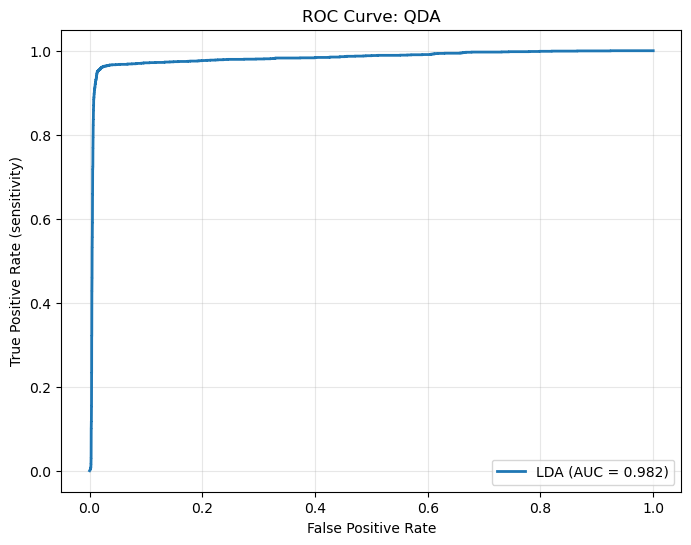

In [15]:
qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train ,y_train )
y_prob = qda.predict_proba(X_test) [:,1] 

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f"LDA (AUC = {roc_auc:.3f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: QDA')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1: AUC = 0.980104
2: AUC = 0.980709
3: AUC = 0.981016
4: AUC = 0.981948


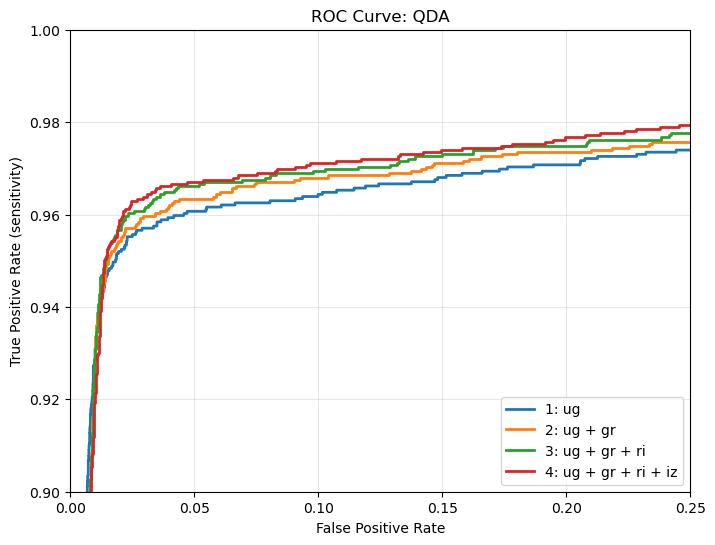

In [16]:
plt.figure(figsize=(8,6))

# ROC line -> we try using different colors (a subset of them first, than all together)
for i in range(4):
    
    X_train_subset = X_train.iloc[:, 0:i+1]
    X_test_subset = X_test.iloc[:, 0:i+1]
    
    qda.fit(X_train_subset, y_train)
    
    y_prob = qda.predict_proba(X_test_subset)[:, 1]
    
    # ROC line and AUC
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{i+1}: AUC = {roc_auc:.6f}")
    
    used_colors = " + ".join(colors_label[0:i+1])
    plt.plot(fpr, tpr, lw=2, label=f"{i+1}: {used_colors}")

plt.ylim([0.9, 1])
plt.xlim([0, 0.25])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: QDA')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In this case, adding information with the subsequent colors made the model perform better.

## GMM Bayes

k best = 14


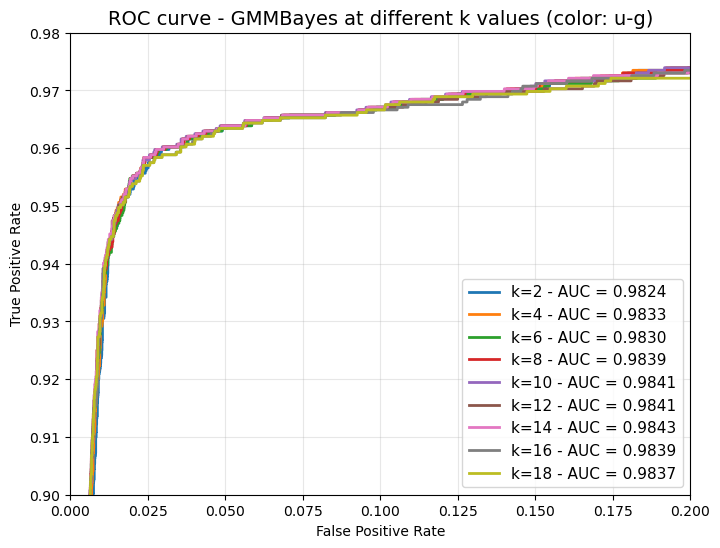

In [17]:
# Let's start frome the color (u-g)
X_train_ug = X_train[['u-g']]
X_test_ug = X_test[['u-g']]

k_values = np.arange(2,20)[::2]
auc_values = []
plt.figure(figsize=(8, 6))

for k in k_values:
    
    gmm = GMMBayes(k, covariance_type='full', random_state=42)
    gmm.fit(X_train_ug, y_train)
    
    y_prob = gmm.predict_proba(X_test_ug)[:, 1]
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_values.append(roc_auc)
    
    plt.plot(fpr, tpr, lw=2, label=f"k={k} - AUC = {roc_auc:.4f}")

k_best = k_values[np.argmax(auc_values)]
print(f"k best = {k_best}")

# 4. Estetica e baseline
plt.xlim([0, 0.2])
plt.ylim([0.9, 0.98])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - GMMBayes at different k values (color: u-g)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

1: AUC = 0.984317
2: AUC = 0.990581
3: AUC = 0.988903
4: AUC = 0.988901


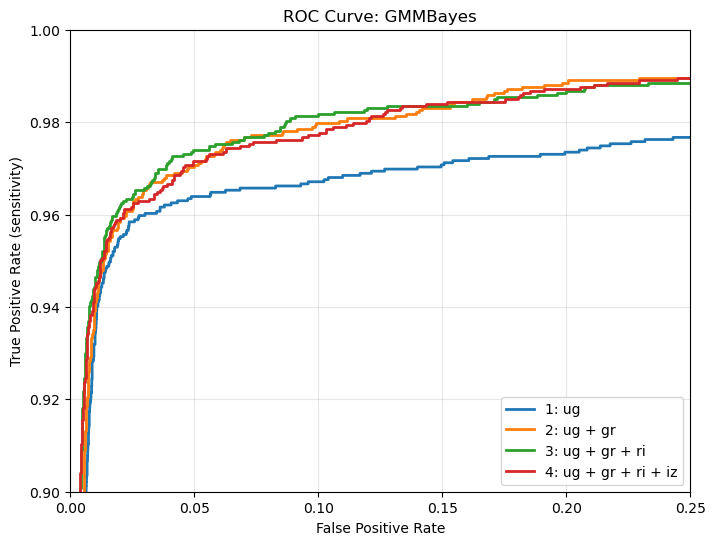

In [18]:
plt.figure(figsize=(8,6))
gmm_best = GMMBayes(k_best, covariance_type='full', random_state=42)

# ROC line -> we try using different colors (a subset of them first, than all together)
for i in range(4):
    
    X_train_subset = X_train.iloc[:, 0:i+1]
    X_test_subset = X_test.iloc[:, 0:i+1]

    gmm_best.fit(X_train_subset, y_train)
    y_prob = gmm_best.predict_proba(X_test_subset)[:, 1]
    
    # ROC line and AUC
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{i+1}: AUC = {roc_auc:.6f}")
    
    used_colors = " + ".join(colors_label[0:i+1])
    plt.plot(fpr, tpr, lw=2, label=f"{i+1}: {used_colors}")

plt.ylim([0.9, 1])
plt.xlim([0, 0.25])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: GMMBayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## K-Neighbours Classifier

In [19]:
# Let's start frome the color (u-g)
n_values = np.arange(2,20)
auc_values_knc = []

for n in n_values:
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train_ug, y_train)
    
    y_prob = clf.predict_proba(X_test_ug)[:, 1]
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_values_knc.append(roc_auc)
    
n_best = n_values[np.argmax(auc_values)]

print(f"n best = {n_best}")

n best = 8


1: AUC = 0.976031
2: AUC = 0.980105
3: AUC = 0.982136
4: AUC = 0.983233


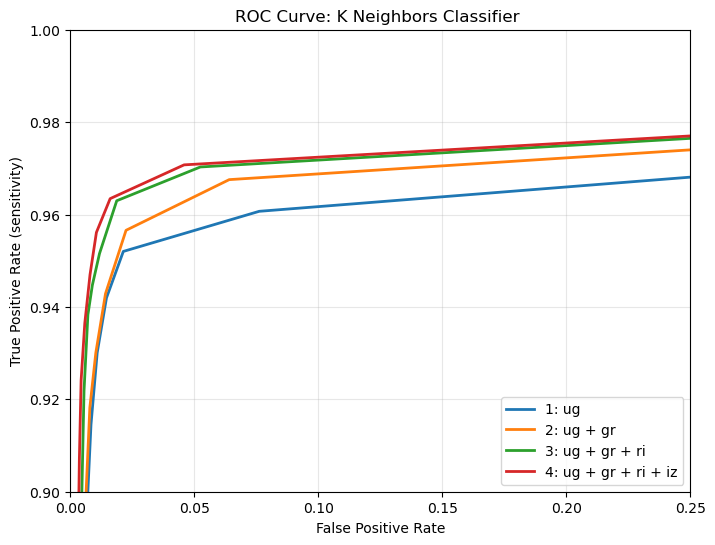

In [22]:
plt.figure(figsize=(8,6))
KN_best = KNeighborsClassifier(n_best)

# ROC line -> we try using different colors (a subset of them first, than all together)
for i in range(4):
    
    X_train_subset = X_train.iloc[:, 0:i+1]
    X_test_subset = X_test.iloc[:, 0:i+1]

    KN_best.fit(X_train_subset, y_train)
    y_prob = KN_best.predict_proba(X_test_subset)[:, 1]
    
    # ROC line and AUC
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{i+1}: AUC = {roc_auc:.6f}")
    
    used_colors = " + ".join(colors_label[0:i+1])
    plt.plot(fpr, tpr, lw=2, label=f"{i+1}: {used_colors}")

plt.ylim([0.9, 1])
plt.xlim([0, 0.25])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: K Neighbors Classifier ')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Comparison of classification models

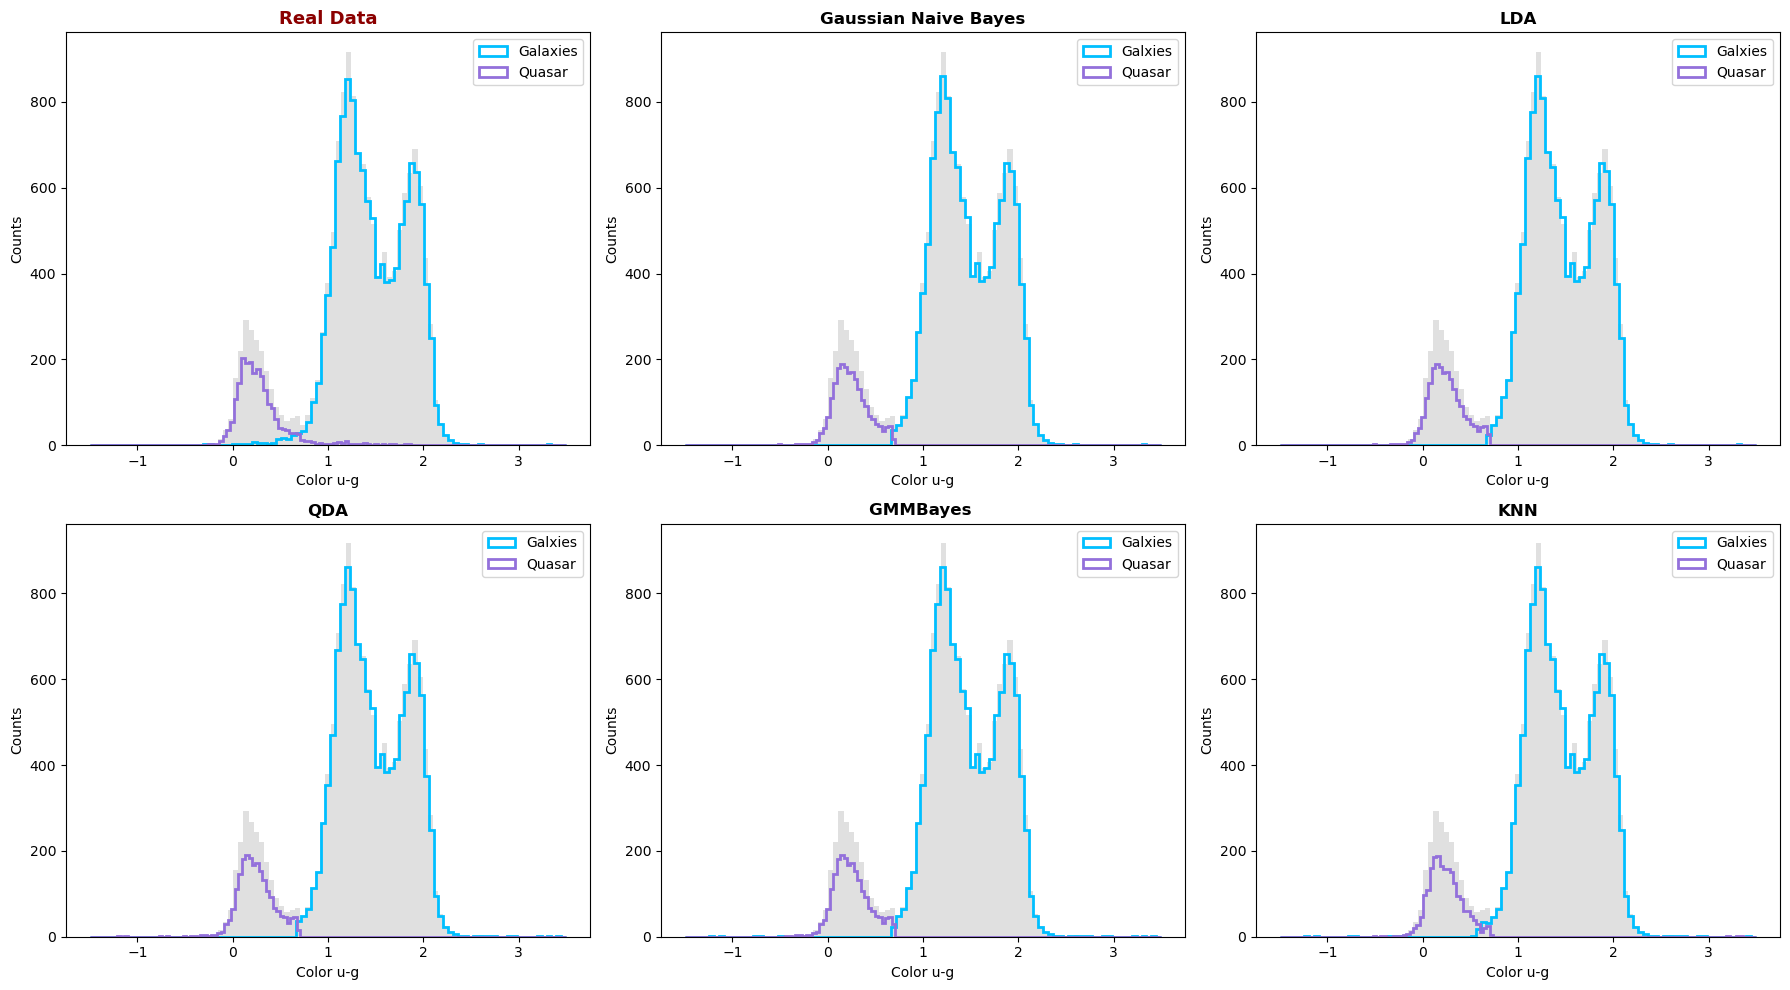

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from astroML.classification import GMMBayes

models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'GMMBayes ': GMMBayes(k_best, covariance_type='full', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=n_best)
}

X_train_ug = X_train[['u-g']]
X_test_ug = X_test[['u-g']]

# 2. Prepariamo la griglia dei grafici (2 righe x 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


# --- real data ---
axes[0].hist(X_test['u-g'], bins='fd', range=(-1.5, 3.5), color='lightgray', alpha=0.7)
axes[0].hist(X_test[y_test == 0]['u-g'], bins='fd', range=(-1.5, 3.5), color='deepskyblue', histtype='step', linewidth=2, label='Galaxies')
axes[0].hist(X_test[y_test == 1]['u-g'], bins='fd', range=(-1.5, 3.5), color='mediumpurple', histtype='step', linewidth=2, label='Quasar')

axes[0].set_title('Real Data', fontsize=13, color='darkred', fontweight='bold')
axes[0].set_xlabel('Color u-g')
axes[0].set_ylabel('Counts')
axes[0].legend(loc='upper right')

# --- Classification model ---
for i, (name, mod) in enumerate(models.items()):
    idx_ax = i + 1
    
    mod.fit(X_train_ug, y_train)
    y_pred = mod.predict(X_test_ug)
    
    # Dati di test
    axes[idx_ax].hist(X_test['u-g'], bins='fd', range=(-1.5, 3.5), color='lightgray', alpha=0.7)
    # Predictions of the classification model
    axes[idx_ax].hist(X_test[y_pred == 0]['u-g'], bins='fd', range=(-1.5, 3.5), color='deepskyblue', histtype='step', linewidth=2, label='Galxies')
    axes[idx_ax].hist(X_test[y_pred == 1]['u-g'], bins='fd', range=(-1.5, 3.5), color='mediumpurple', histtype='step', linewidth=2, label='Quasar')
    
    axes[idx_ax].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx_ax].set_xlabel('Color u-g')
    axes[idx_ax].set_ylabel('Counts')
    axes[idx_ax].legend()

plt.tight_layout()
plt.show()

**All classifiers (linear, quadratic, probabilistic, and distance-based) replicate the real data almost faithfully.
This demonstrates the extremely high discriminatory power of the single u-g photometric feature.**